# **Machine Learning Analysis of Atmospheric CH₄ Time Series**

Following the previous analysis of atmospheric CO₂ using statistical time series models, this analysis applies a **machine learning approach** to atmospheric methane (CH₄) concentrations. The dataset contains **514 monthly observations from July 1983 to April 2026**, providing a long-term record of changes in atmospheric methane levels.

The analysis will investigate how different **machine learning methods** can be used to model and forecast the CH₄ time series. The focus will be on understanding the structure of the data, developing suitable predictive features, training and tuning models, and evaluating their forecasting performance.

The analysis uses a **univariate time-series framework**, where the primary source of predictive information is the historical CH₄ concentration itself. The specific feature engineering, modelling approaches, and evaluation procedures will be introduced and discussed in the sections that follow.


## **1. Loading and Preparing the CO₂ Data**
The dataset is loaded into a `pandas DataFrame`, and a proper monthly date index is created from the `year` and `month` columns. The data is then converted to a **monthly time-series frequency** (`MS`), indicating that observations occur at the start of each month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/ch4_mm_gl.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS")

print(df.head())

            year  month   decimal  average  average_unc    trend  trend_unc
date                                                                       
1983-07-01  1983      7  1983.542  1626.05         2.39  1635.18       1.46
1983-08-01  1983      8  1983.625  1628.02         2.93  1635.67       1.39
1983-09-01  1983      9  1983.708  1638.42         2.20  1636.23       1.31
1983-10-01  1983     10  1983.792  1644.81         1.47  1636.85       1.23
1983-11-01  1983     11  1983.875  1642.60         0.82  1637.55       1.15


### **1.1 Chronological Train-Holdout Split**
Because this is a **time-series dataset**, the observations must remain in chronological order. Randomly splitting the data could introduce **data leakage**, as information from the future could enter the training set. Therefore, the last 24 months are reserved as a **holdout set** for evaluating the model's 24-month-ahead forecasts.

In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1983-07-01 00:00:00 to 2024-04-01 00:00:00
Number of observations: 490

Holdout data:
2024-05-01 00:00:00 to 2026-04-01 00:00:00
Number of observations: 24


## **2. Data analysis**
We begin with an exploratory analysis of the data to develop an understanding of the underlying characteristics of the time series. This initial analysis provides insights into key patterns and properties of the series, which will subsequently guide the feature-engineering process.

### **2.1 Raw Series Inspection**

The raw monthly CH₄ series is first visualized using the `average` variable concentration. This allows us to identify its main time-series characteristics, including overall trends, seasonal patterns, fluctuations, and any potential anomalies.

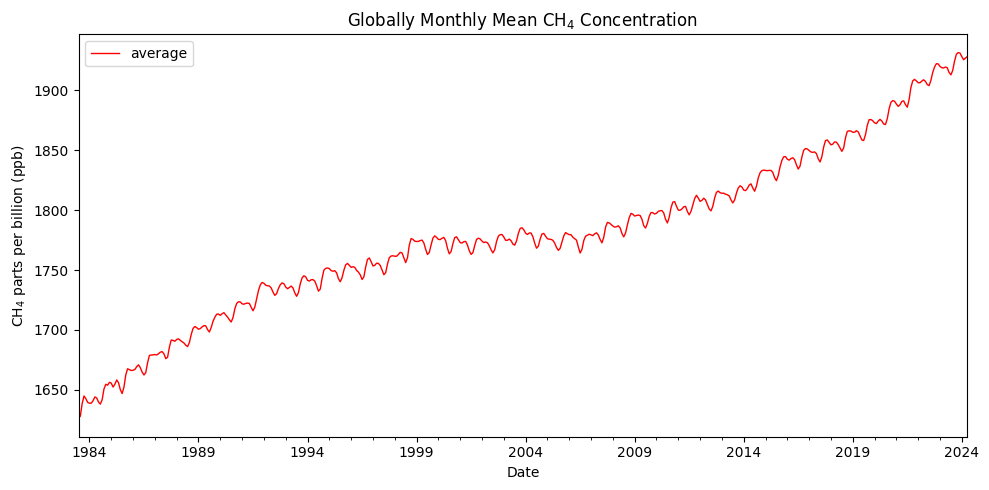

In [3]:
# Plot the raw series
import matplotlib.pyplot as plt

train.plot(y="average",figsize=(10, 5),linewidth=1, color="red")

plt.title("Globally Monthly Mean CH$_4$ Concentration")
plt.xlabel("Date")
plt.ylabel("CH$_4$ parts per billion (ppb)")
plt.tight_layout()
plt.show()

### Raw CH₄ Time Series Analysis

The raw CH₄ series shows a clear **long-term upward trend** in atmospheric methane concentrations over the observation period. The series increases from approximately **1626 ppb in 1983 to values in the 1930s ppb by 2026**, indicating a substantial rise in atmospheric CH₄ over the last four decades. Alongside this long-term trend, the series exhibits a noticeable **seasonal pattern**, with concentrations regularly fluctuating throughout the year.

An interesting feature is the period between approximately **1999 and 2007**, during which the overall increase in CH₄ concentrations appears to temporarily slow or stabilize. This period corresponds to the well-documented global methane growth plateau observed around the early 2000s. After this period, atmospheric CH₄ concentrations resumed their upward trajectory, with the increase becoming particularly pronounced in more recent years.

Overall, the raw series contains several prominent features: a **strong long-term trend, recurring seasonal variation, and a temporary period of near-stagnation**. These characteristics provide an important starting point for the subsequent analysis of the CH₄ time series.


### **2.2 Regular Differencing**

To reduce the **long-term trend** observed in the raw CH₄ series, regular first differencing is applied with a **lag of 1**. This calculates the month-to-month change in atmospheric methane concentration rather than modelling the concentration levels directly.

The differenced series is therefore defined as:

$$\Delta CH_{4,t} = CH_{4,t} - CH_{4,t-1}$$


This transformation removes the level component between consecutive observations and allows the resulting series to be examined separately from the original upward trend.


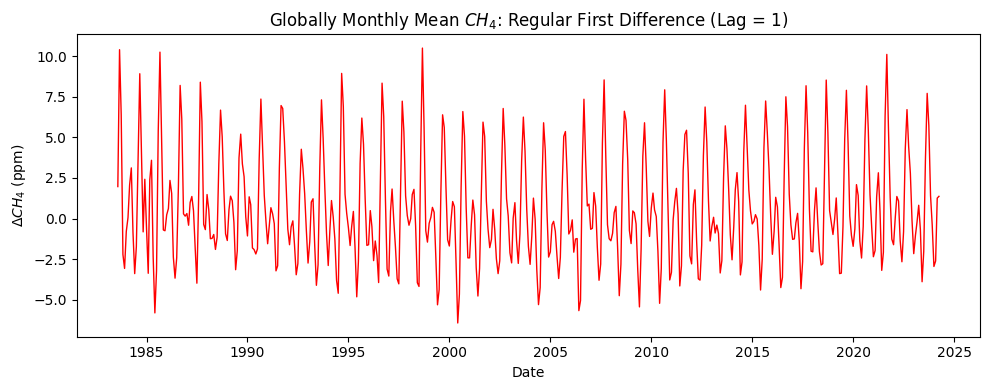

In [4]:
# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1, color="red")
plt.title("Globally Monthly Mean $CH_4$: Regular First Difference (Lag = 1)")
plt.xlabel("Date")
plt.ylabel(r"$\Delta CH_4$ (ppm)")
plt.tight_layout()
plt.show()

### **2.3 ACF and PACF of the Regularly Differenced Series**

After applying regular first differencing, we examine the **autocorrelation function (ACF)** and **partial autocorrelation function (PACF)** of the differenced $CH_4$ series.

The ACF shows how the differenced series is correlated with its previous values at different lags, while the PACF measures the correlation at each lag after accounting for the effects of shorter lags.


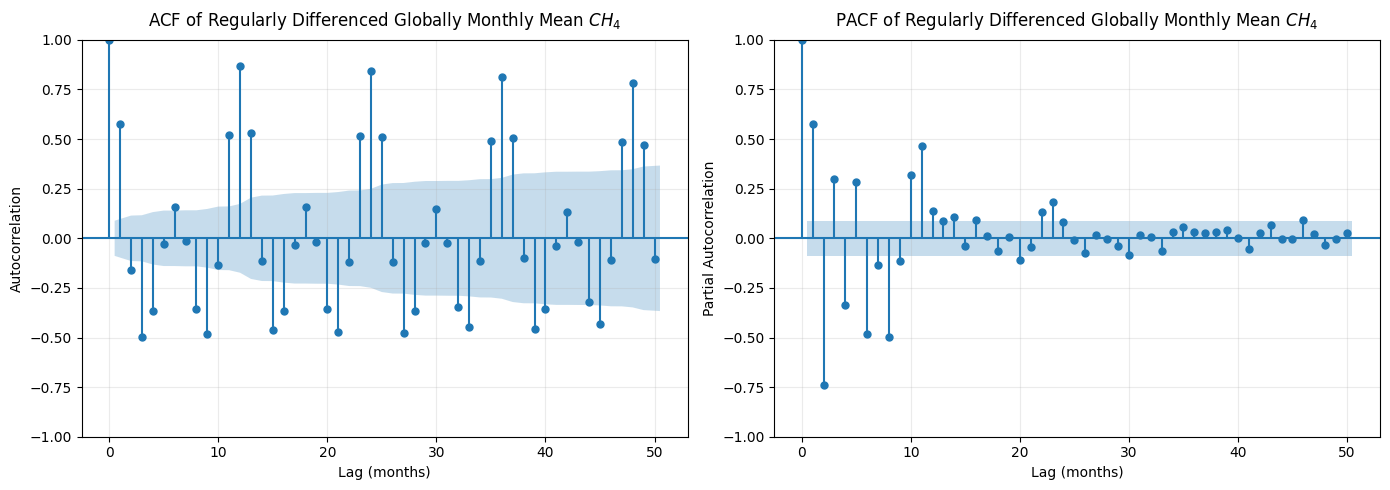

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Regularly differenced series
diff_regular = train["average"].diff(1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ACF ---
plot_acf(diff_regular,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title("ACF of Regularly Differenced Globally Monthly Mean $CH_4$",fontsize=12,pad=10)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_regular,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title("PACF of Regularly Differenced Globally Monthly Mean $CH_4$",fontsize=12,pad=10)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### Observations from the ACF and PACF

The ACF and PACF plots of the first-differenced $CH_4$ series reveal several important patterns that will guide the feature-engineering stage.

- **ACF observations**

The most prominent feature in the ACF is the strong **seasonal structure at multiples of 12 months**. Lag 1 shows a strong and statistically significant positive correlation, while strong positive correlations also appear at lags **12, 24, 36, 48, and 60**. This suggests that annual seasonal pattern remains clearly present in the $CH_4$ series.

An additional and interesting pattern is visible at lags separated by six months. Lags such as **3, 9, 15, 21, 27, 33, ...** show statistically significant negative autocorrelation. This indicates that the differenced series contains a repeating intra-year structure rather than simply a straightforward annual cycle. The alternating positive and negative correlations suggest that observations at certain positions within the seasonal cycle tend to move in opposite directions.

- **PACF observations**

The PACF provides a complementary view of the dependence structure. The first **12 lags contain several statistically significant partial autocorrelations**, with an alternating pattern in which strongly positive and negative coefficients occur at successive lags.

This indicates that the short-term dynamics of the differenced $CH_4$ series cannot be explained by a single previous observation alone. There appears to be meaningful dependence extending across several months, while the strong structure within the first 12 months is consistent with the seasonal behaviour identified in the ACF.

### **2.4 Monthly Distribution of Differenced $CH_4$**

The monthly boxplots show the distribution of **month-to-month changes in $CH_4$** for each calendar month. This provides a complementary view of the seasonal structure identified by the ACF and PACF.

Systematic differences in the median and spread across months would indicate that the magnitude of monthly changes varies seasonally, providing further motivation for incorporating **seasonal lag and calendar-based features**.


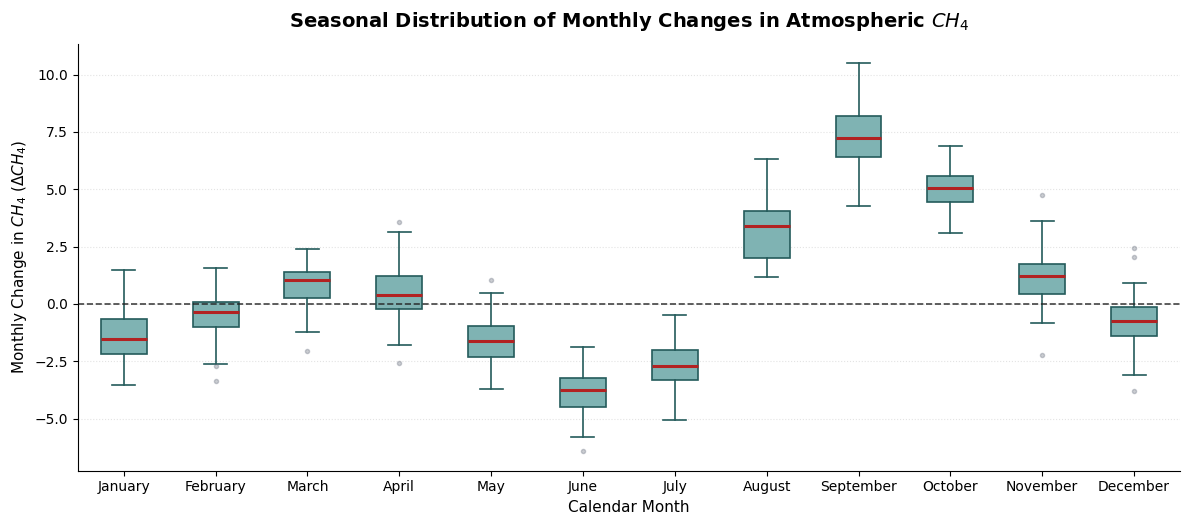

In [6]:
import calendar

# Prepare regularly differenced CH4 series
ch4_diff = train[["diff_regular"]].dropna().copy()

# Extract calendar month
ch4_diff["Month"] = ch4_diff.index.month_name()

# Preserve chronological order
month_order = list(calendar.month_name[1:])
ch4_diff["Month"] = pd.Categorical(ch4_diff["Month"],categories=month_order,ordered=True)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5.5))
ch4_diff.boxplot(column="diff_regular",by="Month",ax=ax,grid=False,patch_artist=True,
    boxprops=dict(facecolor="#7FB3B3",color="#245B5B",linewidth=1.2),
    medianprops=dict(color="#B22222",linewidth=2.2),
    whiskerprops=dict(color="#245B5B",linewidth=1.2),
    capprops=dict(color="#245B5B",linewidth=1.2),
    flierprops=dict(marker="o",markersize=3,markerfacecolor="#6B7280",markeredgecolor="#6B7280",
        alpha=0.35)
)

# Remove pandas automatic title
plt.suptitle("")

# Zero reference line
ax.axhline(0,color="#222222",linestyle="--",linewidth=1.2,alpha=0.85)
# Titles and labels
ax.set_title(r"Seasonal Distribution of Monthly Changes in Atmospheric $CH_4$",
    fontsize=14,fontweight="bold",pad=12)
ax.set_xlabel("Calendar Month",fontsize=11)
ax.set_ylabel(r"Monthly Change in $CH_4$ ($\Delta CH_4$)",fontsize=11)
# Grid
ax.grid(axis="y",linestyle=":",linewidth=0.8,alpha=0.35)
# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Numerical statistics for the regularly differenced CH4 series by month
monthly_stats = (ch4_diff.groupby("Month", observed=True)["diff_regular"]
    .agg(count="count",mean="mean",median="median",std="std",min="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max")
)

# Add interquartile range (IQR)
monthly_stats["IQR"] = monthly_stats["q3"] - monthly_stats["q1"]

# Display rounded results
monthly_stats.round(4)

,count,mean,median,std,min,q1,q3,max,IQR
Month,,,,,,,,,
January,41,-1.4468,-1.55,1.1245,-3.54,-2.2000,-0.6500,1.48,1.5500
February,41,-0.4466,-0.35,1.0561,-3.37,-1.0300,0.0800,1.57,1.1100
March,41,0.7971,1.02,1.0068,-2.07,0.2400,1.3800,2.38,1.1400
April,41,0.4822,0.39,1.3203,-2.59,-0.2100,1.2200,3.59,1.4300
May,40,-1.5457,-1.62,1.0825,-3.71,-2.2975,-0.9650,1.06,1.3325
June,40,-3.8490,-3.75,1.0996,-6.43,-4.4875,-3.2125,-1.87,1.2750
July,40,-2.7360,-2.72,1.1386,-5.05,-3.3200,-2.0100,-0.48,1.3100
August,41,3.2151,3.38,1.2215,1.18,2.0100,4.0300,6.31,2.0200
September,41,7.3459,7.24,1.4772,4.27,6.3900,8.2000,10.50,1.8100


#### Discussion on the Monthly Differenced $CH_4$ Distribution

A clear seasonal pattern is visible across the calendar year. From **January through April**, the distributions remain relatively close to the zero line. A pronounced negative movement then appears in **May and June**, with June showing the strongest negative median change of approximately **−3.75**. The changes remain negative in July, although the magnitude begins to weaken.

The pattern then reverses strongly during **August and September**. August has a positive median change of approximately **+3.38**, while September shows the largest positive median change of approximately **+7.24**. The increase remains positive in October, with a median of approximately **+5.06**, before weakening substantially in November and returning to a negative median in December.

Overall, the most pronounced departures from zero occur between approximately **May and October**. This six-month period contains the strongest seasonal movement in the differenced series. This is consistent with the strong seasonal structure observed in the ACF and suggests that the differenced $CH_4$ series has a substantial within-year seasonal component.

## **3. Feature Engineering and Feature Selection for Machine Learning**
The objective of the feature-engineering stage is to transform the univariate global monthly $CH_4$ concentration series into a supervised learning problem while preserving the chronological structure of the forecasting task. The target variable, which is represented by `average` is the observed monthly methane concentration, and the objective is to predict $CH_4(t)$ using information that would have been available before month $t$.

Because the analysis is explicitly univariate, the predictive information must be extracted primarily from the historical behaviour of the $CH_4$ series itself. The preceding exploratory analysis provides an empirical basis for constructing candidate predictors. In particular, the raw series revealed a strong long-term increase and a pronounced annual seasonality. The ACF and PACF of the differenced series further indicated strong short-term dependence and persistent seasonal structure, while the monthly boxplots showed that the magnitude and direction of monthly changes vary systematically across the calendar year.

These observations motivate the construction of several classes of features, including calendar variables, lagged observations, historical changes, seasonal differences, rolling statistics, and short-term trend measures. However, an important principle is that statistical significance in the exploratory analysis does not automatically imply predictive usefulness in a machine-learning model. The exploratory analysis was therefore used to identify plausible temporal relationships and generate candidate features, while feature selection is ultimately guided by out-of-sample model performance.

In [3]:
import numpy as np
import pandas as pd


def create_ch4_features(dat, target_col="average"):
    """
    Create leakage-free machine-learning features for
    monthly atmospheric CH4 forecasting.

    Every predictor for time t is constructed using information
    available at t-1 or earlier.

    Parameters
    -----
    dat : pandas.DataFrame
        DataFrame indexed by date and containing the target.
    target_col : str
        Name of the CH4 concentration column.

    Returns
    ---
    pandas.DataFrame
        Target plus leakage-free engineered predictors.
    """

    # 0. Copy the DATAFRAME PASSED to the function
    data = dat.copy()
    # Ensure chronological order
    data = data.sort_index()

    # 1. Calendar features
    data["year"] = data.index.year
    data["month"] = data.index.month
    # Decimal year representation
    data["decimal"] = (data.index.year + (data.index.month - 1) / 12)
    # Cyclical representation of annual seasonality
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    # 2. ACF/PACF-informed lag features
    # Selected from the observed temporal structure.
    # lag 1: strong short-term persistence
    # 12, 24, 36, 48: annual / multi-annual persistence
    # 3, 9, 15, 21, 27, 33: lags highlighted by the ACF/PACF structure
    selected_lags = [1,2,3,9,12,15,21,24,27,33,36,48]
    for lag in selected_lags:
        data[f"lag_{lag}"] = (data[target_col].shift(lag))

    # 3. Historical change features
    data["diff_lag_1"] = (data[target_col].shift(1) - data[target_col].shift(2))
    data["diff_lag_2"] = (data[target_col].shift(2)- data[target_col].shift(3))
    data["diff_lag_3"] = (data[target_col].shift(3)- data[target_col].shift(4))
    data["diff_lag_6"] = (data[target_col].shift(6)- data[target_col].shift(7))
    data["diff_lag_12"] = (data[target_col].shift(12)- data[target_col].shift(13))

    # 4. Historical seasonal differences
    # These compare historical observations with the
    # corresponding observations one year earlier.
    data["seasonal_diff_lag_1"] = (data[target_col].shift(1)- data[target_col].shift(13))
    data["seasonal_diff_lag_2"] = (data[target_col].shift(2)- data[target_col].shift(14))
    data["seasonal_diff_lag_3"] = (data[target_col].shift(3)- data[target_col].shift(15))
    data["seasonal_diff_lag_6"] = (data[target_col].shift(6)- data[target_col].shift(18))
    data["seasonal_diff_lag_12"] = (data[target_col].shift(12)- data[target_col].shift(24))

    # 5. Leakage-free rolling statistics
    # We shift before rolling. 
    # Therefore, rolling statistics at time t contain: t-1, t-2, ..., t-window and never t.
    shifted_target = (data[target_col].shift(1))
    rolling_windows = [1,2,3,6,12]
    for window in rolling_windows:
        data[f"rolling_mean_{window}"] = (shifted_target
            .rolling(window=window,min_periods=window)
            .mean())
        data[f"rolling_std_{window}"] = (shifted_target
            .rolling(window=window,min_periods=window)
            .std())

    # 6. Historical trend features
    data["trend_1_2"] = (data["rolling_mean_1"]- data["rolling_mean_2"])
    data["trend_2_3"] = (data["rolling_mean_2"]- data["rolling_mean_3"])
    data["trend_3_6"] = (data["rolling_mean_3"]- data["rolling_mean_6"])
    data["trend_6_12"] = (data["rolling_mean_6"]- data["rolling_mean_12"])

    # 7. Explicitly select ONLY intended variables
    feature_columns = [
        # Calendar
        "year","month","decimal","month_sin","month_cos",
        # ACF/PACF-informed lags
        "lag_1","lag_2","lag_3","lag_9","lag_12","lag_15","lag_21","lag_24","lag_27","lag_33","lag_36","lag_48",
        # Historical changes
        "diff_lag_1","diff_lag_2","diff_lag_3","diff_lag_6","diff_lag_12",
        # Historical seasonal changes
        "seasonal_diff_lag_1","seasonal_diff_lag_2","seasonal_diff_lag_6","seasonal_diff_lag_12",
        # Historical rolling statistics
        "rolling_mean_3","rolling_std_3","rolling_mean_6","rolling_std_6","rolling_mean_12","rolling_std_12",
        # Historical trend
        "trend_1_2","trend_2_3","trend_3_6","trend_6_12"
    ]
    # Keep target + intended predictors only
    data = data[[target_col] + feature_columns].copy()

    # 8. Remove rows without sufficient historical information
    # The longest required history is 48 months.
    # This mean rows before sufficient history exists cannot be used
    # because their engineered predictors contain NaN values.
    data = data.dropna().copy()

    return data


In [4]:
# Create  CH4 feature matrix
ch4_features = create_ch4_features(train,target_col="average")

def select_model_features(ch4_features, target_col="average"):
    dropped_features = ["year","decimal","lag_3","lag_9","lag_15","lag_21","lag_24","lag_27",
        "lag_33","lag_36","lag_48","rolling_std_3","rolling_mean_6","rolling_std_6","diff_lag_6",
        "seasonal_diff_lag_6","seasonal_diff_lag_12","trend_6_12"]

    X = ch4_features.drop(columns=[target_col] + dropped_features).copy()

    return X

# Separate predictors and target
X = select_model_features(ch4_features,target_col="average")
y = ch4_features["average"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

Feature matrix shape: (442, 18)
Target shape: (442,)

Feature names:
['month', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_12', 'diff_lag_1', 'diff_lag_2', 'diff_lag_3', 'diff_lag_12', 'seasonal_diff_lag_1', 'seasonal_diff_lag_2', 'rolling_mean_3', 'rolling_mean_12', 'rolling_std_12', 'trend_1_2', 'trend_2_3', 'trend_3_6']


### **3.1 From Candidate Features to the Final Feature Set**

The feature-engineering stage initially produces a relatively broad set of candidate predictors. This is intentional: the ACF/PACF and distributional analysis identify several potentially useful forms of temporal information, but they do not determine which features will ultimately improve forecasting performance.

Many of the candidate variables are also related. For example, lagged concentrations, rolling means, historical differences, seasonal differences, and trend measures can contain overlapping information. Including all of them may therefore add complexity without adding predictive information.

Feature selection was consequently treated as an **empirical modelling decision**. Initial models were evaluated with the broader feature set, after which features or groups of features were removed where their exclusion produced improved validation performance. The holdout period was kept separate from this process and is reserved for the final evaluation.

This iterative process reduced the candidate feature set from **36 predictors to 18**. The resulting feature set retains complementary information about:

-  **Seasonality:** `month`, `month_sin`, `month_cos`
- **Recent concentration levels:** `lag_1`, `lag_2`, `lag_12`
- **Recent changes:** `diff_lag_1`, `diff_lag_2`, `diff_lag_3`, `diff_lag_12`
- **Year-over-year behaviour:** `seasonal_diff_lag_1`, `seasonal_diff_lag_2`
- **Recent level and variability:** `rolling_mean_3`, `rolling_mean_12`, `rolling_std_12`
- **Short-term trend:** `trend_1_2`, `trend_2_3`, `trend_3_6`

The final set is therefore not intended to represent every temporal relationship present in the data. Rather, it represents the subset that provided the most useful predictive information in the model-development experiments while avoiding unnecessary redundancy.


## **4. Linear Regression Models**

The first modelling stage uses a family of linear regression models. These models provide an interpretable results for univariate series and allow us to evaluate how much of the monthly atmospheric $CH_4$ variation can be explained using the engineered temporal and seasonal features.

This is particularly useful for our dataset because the feature-engineering analysis has produced a relatively rich set of predictors despite the limited number of external explanatory variables. The predictors include lagged $CH_4$ concentrations, lagged changes, seasonal lags, rolling statistics, calendar features, and cyclical month variables.

### **4.1 Ordinary Least Squares Linear Regression**

Ordinary Least Squares (OLS) provides the simplest baseline:

$$
\hat{y}_t =
\beta_0 +
\beta_1 X_{1,t} +
\beta_2 X_{2,t} +
\cdots +
\beta_p X_{p,t}
$$

The coefficients are estimated by minimizing the sum of squared residuals:

$$
\min_{\beta}
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
$$

OLS is useful as a baseline because it provides a direct measure of how well a linear relationship between the engineered features and future $CH_4$ concentration performs.

### **4.2 Ridge Regression**

Ridge regression extends OLS by adding an $L_2$ penalty to the coefficient estimates:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\lambda\sum_{j=1}^{p}\beta_j^2
\right]
$$

The parameter $\lambda$ controls the strength of regularization. Larger values shrink coefficients more strongly toward zero. Ridge is particularly appropriate for this problem because many of our lagged and rolling features are likely to be correlated. Rather than allowing correlated predictors to produce unstable coefficient estimates, Ridge distributes their influence more smoothly. The Ridge hyperparameter $\lambda$ will therefore be tuned using expanding-window time-series cross-validation.

### **4.3 Lasso Regression**

Lasso uses an $L_1$ penalty:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\lambda\sum_{j=1}^{p}|\beta_j|
\right]
$$

Unlike Ridge, the Lasso penalty can shrink some coefficients exactly to zero. This effectively performs feature selection. Lasso is useful here because we have alot of engineered features, several of which may contain overlapping information. A successful Lasso model could indicate that only a smaller subset of the engineered features is necessary for prediction. However, when predictors are strongly correlated, Lasso can behave unpredictably by selecting one variable from a group of correlated predictors while excluding another similar variable.

### **4.4 Elastic Net**

Elastic Net combines the $L_1$ and $L_2$ penalties:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\lambda
\left(
\rho\sum_{j=1}^{p}|\beta_j|
+
(1-\alpha)\sum_{j=1}^{p}\beta_j^2
\right)
\right]
$$

where $\lambda$ controls the overall regularization strength and $\alpha$ controls the balance between the Lasso and Ridge penalties. Elastic Net is particularly useful when there are groups of correlated predictors, as is expected in our lagged feature set. It can retain groups of related variables while still encouraging unnecessary features toward zero.

### **4.5 Time-Series Validation and Hyperparameter Tuning**

Random train-test splitting or ordinary random K-fold cross-validation will not be used. Such approaches could allow observations from later periods to influence the model while evaluating earlier periods, which would violate the temporal structure of the forecasting problem. Instead, model selection will use **expanding-window validation**. In each validation fold, the model is trained using observations from the beginning of the series up to a particular point and then evaluated on the immediately following observations.

For Ridge, Lasso, and Elastic Net, hyperparameters will be selected using the mean validation error across the expanding folds. Feature scaling will be performed within each validation split using a `Pipeline`, ensuring that the scaler is fitted only on the training portion of each fold.

The primary evaluation metrics will be:

- **MAE (Mean Absolute Error):** average absolute forecasting error and an easily interpretable measure of prediction accuracy.
- **RMSE (Root Mean Squared Error):** penalizes larger errors more heavily than MAE.
- **$R^2$:** measures the proportion of variance explained relative to a constant-mean baseline.
- **MAPE (Mean Absolute Percentage Error):** expresses the error as a percentage of the observed value. Because atmospheric $CH_4$ concentrations are strictly positive and far from zero, MAPE is usable here, although it will not be treated as the primary metric.

The final model comparison will be based primarily on out-of-sample MAE and RMSE, while $R^2$ and MAPE provide additional perspectives on performance.


In [5]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# 1. Chronological train/validation structure
tscv = TimeSeriesSplit(n_splits=5)

# 2. Define models
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),("model", Ridge())
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),("model", Lasso(max_iter=100000))
    ]),
    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),("model", ElasticNet(max_iter=100000))
    ])
}

# 3. Hyperparameter grids
param_grids = {
    # OLS has no regularization parameter to tune
    "Linear Regression": {},
    # Ridge regularization strength
    "Ridge": {"model__alpha": np.logspace(-4, 4, 30)},
    # Lasso regularization strength
    "Lasso": {"model__alpha": np.logspace(-4, 1, 30)},
    # Elastic Net: alpha = overall regularization strength & l1_ratio = balance between L1 and L2 penalties
    "Elastic Net": {"model__alpha": np.logspace(-4, 1, 20),
        "model__l1_ratio": [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 0.90, 0.95]
    }
}

# 4. Tune each model using chronological CV
search_results = {}
best_models = {}
for name, model in models.items():
    print("=" * 70)
    print(f"Tuning: {name}")
    print("=" * 70)
    search = GridSearchCV(estimator=model,param_grid=param_grids[name],
        scoring="neg_mean_absolute_error",cv=tscv,n_jobs=-1,refit=True
    )
    search.fit(X, y)
    search_results[name] = search
    best_models[name] = search.best_estimator_
    print("Best parameters:")
    print(search.best_params_)
    print(f"Best CV MAE: "f"{-search.best_score_:.4f}")
    print()

Tuning: Linear Regression
Best parameters:
{}
Best CV MAE: 0.7970

Tuning: Ridge
Best parameters:
{'model__alpha': np.float64(0.03039195382313198)}
Best CV MAE: 0.7788

Tuning: Lasso
Best parameters:
{'model__alpha': np.float64(0.001082636733874054)}
Best CV MAE: 0.7741

Tuning: Elastic Net
Best parameters:
{'model__alpha': np.float64(0.00018329807108324357), 'model__l1_ratio': 0.2}
Best CV MAE: 0.7753



In [6]:
from sklearn.base import clone

# Chronological evaluation of tuned models
evaluation_splits = TimeSeriesSplit(n_splits=5)
model_results = []
for name, tuned_model in best_models.items():
    fold_mae = []
    fold_rmse = []
    fold_r2 = []
    fold_mape = []
    for train_idx, test_idx in evaluation_splits.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        # Clone the already-selected model
        model = clone(tuned_model)
        # Fit only on earlier observations
        model.fit(X_train, y_train)
        # Predict later observations
        y_pred = model.predict(X_test)
        # Metrics
        mae = mean_absolute_error(y_test,y_pred)
        rmse = np.sqrt(mean_squared_error(y_test,y_pred))
        r2 = r2_score(y_test,y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_r2.append(r2)
        fold_mape.append(mape)
    # Average performance across chronological folds
    model_results.append({"Model": name,"MAE": np.mean(fold_mae),"RMSE": np.mean(fold_rmse),
        "R2": np.mean(fold_r2),"MAPE (%)": np.mean(fold_mape)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(model_results)
# Rank primarily by MAE
results_df = results_df.sort_values(by="MAE",ascending=True).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2,MAPE (%)
0,Lasso,0.774118,0.965492,0.990847,0.042830
1,Elastic Net,0.775266,0.965564,0.990886,0.042885
2,Ridge,0.778825,0.971033,0.990875,0.043075
3,Linear Regression,0.797039,0.988434,0.990309,0.044059


### **4.6 Final Chronological Model Comparison**

The final chronological evaluation shows that all four models achieve very strong forecasting performance, with $R^2$ values close to 0.99.

| Model | MAE | RMSE | $R^2$ | MAPE (%) |
|---|---:|---:|---:|---:|
| Lasso | 0.7741 | 0.9655 | 0.9908 | 0.0428 |
| Elastic Net | 0.7753 | 0.9656 | 0.9909 | 0.0429 |
| Ridge | 0.7788 | 0.9710 | 0.9909 | 0.0431 |
| Linear Regression | 0.7970 | 0.9884 | 0.9903 | 0.0441 |

#### Results and Interpretation

**Lasso achieved the lowest MAE and RMSE**, with $MAE=0.7741$ and $RMSE=0.9655$, making it the best model according to these error measures. Its $R^2=0.9908$ indicates that approximately 99% of the variation in the chronological test period is explained by the model.

Elastic Net achieved a marginally higher $R^2$ of 0.9909, but its MAE and RMSE were almost identical to those of Lasso. The differences between Lasso, Elastic Net, and Ridge are therefore negligible in practical terms.

Compared with ordinary Linear Regression, the regularized models achieved lower MAE and RMSE. This suggests that regularization provides a modest improvement when using the engineered temporal features, which contain correlated and overlapping information.

The selected Lasso hyperparameter was:

$$
\alpha = 0.0010826
$$

Overall, the results indicate that the engineered lag, difference, trend, and seasonal features capture most of the predictable temporal structure in the monthly $CH_4$ series. **Lasso is selected as the final model based on its lowest MAE and RMSE, although the three regularized models show essentially equivalent predictive performance.**


## **5. Support Vector Regression with an RBF Kernel**

Support Vector Regression (SVR) provides a nonlinear approach to forecasting monthly atmospheric $CH_4$. It is particularly suitable for this dataset because we have a relatively small number of observations, a moderate number of engineered features, and evidence of smooth temporal and seasonal dynamics.

Unlike linear regression, SVR does not require the relationship between the engineered features and the target to be linear. With a **Radial Basis Function (RBF) kernel**, observations can influence one another according to their similarity in the feature space. The RBF kernel is defined as:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

where $\gamma$ controls how rapidly the influence of one observation decreases as its distance from another observation increases. The resulting model can therefore represent nonlinear relationships between combinations of lagged $CH_4$ values, seasonal features, rolling statistics, and recent changes.

### **5.1 The SVR objective**

SVR attempts to find a function that predicts the target while allowing errors within an $\epsilon$-insensitive region:

$$
|y_i-f(x_i)| \leq \epsilon
$$

Errors outside this region are penalized. The parameter $\epsilon$ therefore controls the width of the insensitive region around the fitted function. The parameter $C$ controls the trade-off between model complexity and tolerance for training errors. A larger $C$ places greater emphasis on fitting the training observations, while a smaller $C$ produces a more regularized model. For the RBF kernel, $\gamma$ additionally controls the flexibility of the nonlinear relationship:

- small $\gamma$ produces smoother, broader relationships;
- large $\gamma$ allows more localized and flexible relationships.

The three important hyperparameters are therefore:

- `C`, `epsilon` and `gamma`

### **5.2 Feature Scaling**

SVR is highly sensitive to the scale of the predictors because the RBF kernel is based on distances between observations. Our feature matrix contains variables on very different scales. For example, the $CH_4$ concentration, lagged differences, rolling statistics, and cyclical sine/cosine variables have very different numerical ranges. Therefore, all predictors will be standardized before fitting the SVR.

### **5.3 Hyperparameter Tuning**

SVR performance can be highly sensitive to the choice of $C$, $\gamma$, and $\epsilon$. These parameters will therefore be tuned using the same **expanding-window time-series cross-validation** used for the previous models. Random K-fold cross-validation will not be used because it would break the chronological structure of the forecasting problem.

The search will consider a logarithmic range of values for $C$ and $\gamma$ because their useful scales can differ substantially. A smaller grid is initially used to keep the computational cost reasonable given the five chronological folds.

### **5.4 Evaluation**

The tuned SVR will be evaluated using the same metrics as the previous models: **MAE**, **RMSE**, **$R^2$** and **MAPE**.

The same engineered dataset also is used. This ensures that any difference in performance is attributable to the modelling approach rather than a different feature set. The 24-month holdout remains completely untouched and will only be used after the candidate models have been compared and the final model has been selected.


In [7]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# 2. Chronological cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# 3. SVR pipeline
# Scaling is essential for RBF-SVR.
# The scaler is inside the pipeline so that it is fitted
# independently within each training fold.
svr_pipeline = Pipeline([("scaler", StandardScaler()),("model", SVR(kernel="rbf"))])

# 4. Hyperparameter grid
svr_param_grid = {
    # Regularization strength
    "model__C": [100,300,1000,3000,10000],
    # Width of epsilon-insensitive region
    "model__epsilon": [0.01,0.05,0.10,0.20,0.30,0.50],
    # RBF kernel flexibility
    "model__gamma": [0.00005,0.0001,0.0002,0.0005,0.001,0.002,0.005,0.01]
}

# 5. Grid search
svr_search = GridSearchCV(estimator=svr_pipeline,param_grid=svr_param_grid,
    scoring="neg_mean_absolute_error",cv=tscv,n_jobs=-1,refit=True,verbose=1
)

# 6. Fit
svr_search.fit(X, y)

# 7. Best model
best_svr = svr_search.best_estimator_
print("\n" + "=" * 70)
print("BEST RBF-SVR")
print("=" * 70)
print("Best parameters:")
print(svr_search.best_params_)
print(f"\nBest chronological CV MAE: "f"{-svr_search.best_score_:.4f}")

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

BEST RBF-SVR
Best parameters:
{'model__C': 10000, 'model__epsilon': 0.5, 'model__gamma': 0.0001}

Best chronological CV MAE: 0.8737


In [8]:
from sklearn.base import clone
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Chronological evaluation of tuned SVR
evaluation_splits = TimeSeriesSplit(n_splits=5)
svr_mae = []
svr_rmse = []
svr_r2 = []
svr_mape = []
for train_idx, test_idx in evaluation_splits.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    # Fresh copy of the tuned pipeline
    model = clone(best_svr)
    # Fit only on earlier observations
    model.fit(X_train, y_train)
    # Predict later observations
    y_pred = model.predict(X_test)
    # MAE
    mae = mean_absolute_error(y_test,y_pred)
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    # R2
    r2 = r2_score(y_test,y_pred)
    # MAPE
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    svr_mae.append(mae)
    svr_rmse.append(rmse)
    svr_r2.append(r2)
    svr_mape.append(mape)

# Store SVR results
svr_results = {"Model": "SVR (RBF)","MAE": np.mean(svr_mae),"RMSE": np.mean(svr_rmse),
    "R2": np.mean(svr_r2),"MAPE (%)": np.mean(svr_mape)
}

print("\n" + "=" * 70)
print("SVR (RBF) CHRONOLOGICAL VALIDATION")
print("=" * 70)
print(f"MAE:      {svr_results['MAE']:.4f}")
print(f"RMSE:     {svr_results['RMSE']:.4f}")
print(f"R²:       {svr_results['R2']:.4f}")
print(f"MAPE:     {svr_results['MAPE (%)']:.2f}%")


SVR (RBF) CHRONOLOGICAL VALIDATION
MAE:      0.8737
RMSE:     1.0945
R²:       0.9884
MAPE:     0.05%


In [10]:
# COMBINE ALL CHRONOLOGICAL MODEL RESULTS
# Make a copy to avoid modifying the original results_df
results_all_models = results_df.copy()
# Convert SVR results dictionary to DataFrame
svr_results_df = pd.DataFrame([svr_results])
# Add SVR to the existing model results
results_all_models = pd.concat([results_all_models,svr_results_df],ignore_index=True)

# Rank models by MAE
results_all_models = (results_all_models.sort_values(by="MAE",ascending=True).reset_index(drop=True))

# Print complete model comparison
print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON — CHRONOLOGICAL VALIDATION")
print("=" * 80)

print(results_all_models.to_string(index=False,
        formatters={"MAE": "{:.4f}".format,"RMSE": "{:.4f}".format,
                    "R2": "{:.4f}".format,"MAPE (%)": "{:.2f}".format}
    )
)

# Best overall model
best_model_name = results_all_models.iloc[0]["Model"]
best_row = results_all_models.iloc[0]

print("\n" + "=" * 80)
print("BEST OVERALL MODEL")
print("=" * 80)

print(f"Model: {best_model_name}")
print(f"MAE:   {best_row['MAE']:.4f}")
print(f"RMSE:  {best_row['RMSE']:.4f}")
print(f"R²:    {best_row['R2']:.4f}")
print(f"MAPE:  {best_row['MAPE (%)']:.2f}%")

print("\nBest hyperparameters:")

if best_model_name in search_results: print(search_results[best_model_name].best_params_)


FINAL MODEL COMPARISON — CHRONOLOGICAL VALIDATION
            Model    MAE   RMSE     R2 MAPE (%)
            Lasso 0.7741 0.9655 0.9908     0.04
      Elastic Net 0.7753 0.9656 0.9909     0.04
            Ridge 0.7788 0.9710 0.9909     0.04
Linear Regression 0.7970 0.9884 0.9903     0.04
        SVR (RBF) 0.8737 1.0945 0.9884     0.05

BEST OVERALL MODEL
Model: Lasso
MAE:   0.7741
RMSE:  0.9655
R²:    0.9908
MAPE:  0.04%

Best hyperparameters:
{'model__alpha': np.float64(0.001082636733874054)}


### **5.5 RBF-SVR Model and Comparison with the Regularized Linear Models**

The RBF-SVR model was evaluated as a nonlinear alternative to the regularized linear models using five-fold chronological cross-validation over 240 hyperparameter combinations, resulting in 1,200 model fits.

The best-performing configuration was:

$$
C=10000,\qquad \epsilon=0.5,\qquad \gamma=0.0001
$$

with a chronological cross-validation MAE of:

$$
MAE=0.8737.
$$

The final chronological validation results were:

| Model | MAE | RMSE | $R^2$ | MAPE (%) |
|---|---:|---:|---:|---:|
| Lasso | 0.7741 | 0.9655 | 0.9908 | 0.0428 |
| Elastic Net | 0.7753 | 0.9656 | 0.9909 | 0.0429 |
| Ridge | 0.7788 | 0.9710 | 0.9909 | 0.0431 |
| Linear Regression | 0.7970 | 0.9884 | 0.9903 | 0.0441 |
| RBF-SVR | 0.8737 | 1.0945 | 0.9884 | 0.0500 |

#### Results and Interpretation

The RBF-SVR achieved strong predictive performance, with:

$$
MAE=0.8737,\qquad RMSE=1.0945,\qquad R^2=0.9884,
$$

and a MAPE of $0.05\%$. However, it performed worse than all four linear models across the main error metrics.

Compared with Lasso, which achieved the lowest MAE of $0.7741$, the RBF-SVR has an MAE approximately $0.10$ concentration units higher. Its $R^2$ of $0.9884$ is also slightly lower than the approximately $0.99$ achieved by the linear models.

These results suggest that the additional nonlinear flexibility of the RBF kernel does not provide a predictive advantage for the current feature representation. The engineered lag, difference, trend, and seasonal features already capture most of the predictable temporal structure in the monthly $CH_4$ series.

The result therefore supports the use of the simpler regularized linear models. In particular, **Lasso remains the preferred model based on the lowest MAE and RMSE**, while the RBF-SVR provides no evidence of improved forecasting performance.

Overall, the comparison suggests that for this dataset, **careful temporal feature engineering is more important than increasing model complexity**.


## **6. 24-Month Ahead Recursive Forecast Using the Best Model (Lasso)**

OUT-OF-FOLD RESIDUAL UNCERTAINTY
Number of OOF residuals: 365
Residual standard deviation: 0.9514

24-MONTH CH4 FORECAST
            forecast  lower_95  upper_95
2024-05-01 1927.0644 1925.1996 1928.9293
2024-06-01 1923.9569 1921.3197 1926.5942
2024-07-01 1922.4713 1919.2413 1925.7012
2024-08-01 1925.5626 1921.8330 1929.2923
2024-09-01 1932.1669 1927.9970 1936.3368
2024-10-01 1937.6712 1933.1034 1942.2391
2024-11-01 1939.2627 1934.3289 1944.1966
2024-12-01 1938.6187 1933.3442 1943.8932
2025-01-01 1937.1590 1931.5646 1942.7535
2025-02-01 1936.0899 1930.1928 1941.9870
2025-03-01 1937.1073 1930.9224 1943.2923
2025-04-01 1938.5798 1932.1198 1945.0397
2025-05-01 1937.5888 1930.8651 1944.3125
2025-06-01 1934.5099 1927.5323 1941.4874
2025-07-01 1933.0327 1925.8103 1940.2551
2025-08-01 1935.9820 1928.5227 1943.4413
2025-09-01 1942.3873 1934.6984 1950.0762
2025-10-01 1948.2535 1940.3417 1956.1653
2025-11-01 1950.5908 1942.4622 1958.7193
2025-12-01 1950.2508 1941.9111 1958.5906
2026-01-01 1949.27

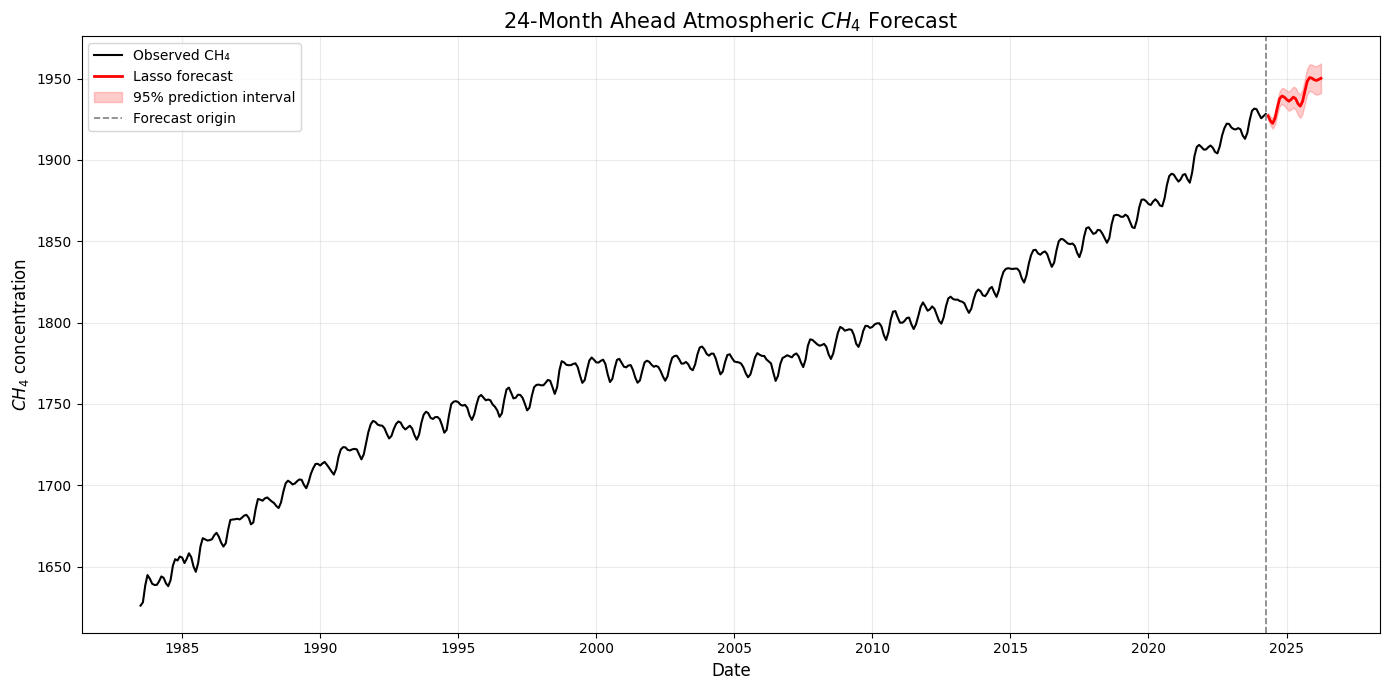

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

# 1. Settings
target_col = "average"
forecast_horizon = 24
best_alpha = 0.001082636733874054
confidence_level = 0.95

# 2. Prepare historical data
historical_data = train.copy()
historical_data = historical_data.sort_index()
y_original = historical_data[target_col].copy()

# 3. Create historical feature matrix
ch4_features = create_ch4_features(historical_data,target_col=target_col)
# IMPORTANT: We use exactly the same feature-selection function
# that was used during model training.
X_full = select_model_features(ch4_features,target_col=target_col)
y_full = ch4_features[target_col]

# 4. Define final Lasso model
final_lasso = Pipeline([("scaler", StandardScaler()),("model", Lasso(
        alpha=best_alpha,max_iter=100000
    ))
])

# 5. Estimate historical out-of-fold residuals
# These residuals are used to estimate forecast uncertainty
# We use chronological folds rather than random CV.
tscv_residuals = TimeSeriesSplit(n_splits=5)
oof_predictions = pd.Series(index=y_full.index,dtype=float)
for fold, (train_idx, test_idx) in enumerate(
    tscv_residuals.split(X_full),start=1
):
    X_train = X_full.iloc[train_idx]
    X_test = X_full.iloc[test_idx]
    y_train = y_full.iloc[train_idx]
    fold_model = clone(final_lasso)
    fold_model.fit(X_train,y_train)
    oof_predictions.iloc[test_idx] = (fold_model.predict(X_test))
# Remove observations for which an OOF prediction
# was not available.
valid_residuals = (y_full[oof_predictions.notna()]
    - oof_predictions[oof_predictions.notna()]
)

# 6. Calculate residual uncertainty
residual_std = valid_residuals.std(ddof=1)
print("=" * 70)
print("OUT-OF-FOLD RESIDUAL UNCERTAINTY")
print("=" * 70)
print(f"Number of OOF residuals: "f"{len(valid_residuals)}")
print(f"Residual standard deviation: "f"{residual_std:.4f}")
print()

# 7. Fit final model on ALL historical data
final_lasso.fit(X_full,y_full)

# 8. Prepare recursive forecasting series
forecast_series = historical_data[target_col].copy()
forecast_series = forecast_series.sort_index()

# 9. Generate future dates
last_observed_date = forecast_series.index[-1]
future_dates = pd.date_range(
    start=last_observed_date + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,freq="MS"
)

# 10. Recursive forecasting
future_predictions = []

for future_date in future_dates:
    # Create temporary dataset containing historical values
    # and predictions generated so far.
    temp_df = pd.DataFrame({target_col: forecast_series})
    # The target at the forecast date itself is not used by
    # any of the engineered predictors because all predictors
    # are lagged by at least one month.
    temp_df.loc[future_date,target_col] = 0.0
    temp_df = temp_df.sort_index()
    # Generate features
    temp_features = create_ch4_features(temp_df,target_col=target_col)
    # Apply SAME feature selection used during training
    temp_features = select_model_features(
        temp_features,target_col=target_col
    )
    # Check future row
    if future_date not in temp_features.index:
        raise ValueError(f"Could not create features for {future_date}")
    # Extract future predictors
    X_future = temp_features.loc[[future_date]]
    # Ensure EXACT same feature order as training
    X_future = X_future[X_full.columns]
    # Forecast
    prediction = final_lasso.predict(X_future)[0]
    # Store prediction
    future_predictions.append(prediction)
    # Add prediction to series so that the next forecast can
    # use it as historical information.
    forecast_series.loc[future_date] = prediction

# 11. Create forecast dataframe
forecast_df = pd.DataFrame({"forecast": future_predictions}, index=future_dates)

# 12. Construct 95% prediction intervals
# A simple residual-based interval is:
# forecast +/- z * residual_std
# This is a practical approximation, not an exact analytical
z_value = 1.96
horizon = np.arange(1,forecast_horizon + 1)
forecast_std = (residual_std* np.sqrt(horizon))
forecast_df["lower_95"] = (forecast_df["forecast"]- z_value * forecast_std)
forecast_df["upper_95"] = (forecast_df["forecast"]+ z_value * forecast_std)

# 13. Display forecast table
print("=" * 70)
print("24-MONTH CH4 FORECAST")
print("=" * 70)
print(forecast_df.to_string(formatters={
            "forecast": "{:.4f}".format,
            "lower_95": "{:.4f}".format,
            "upper_95": "{:.4f}".format
        }
    )
)

# 14. Plot historical data + forecast + prediction interval
plt.figure(figsize=(14, 7))
# Historical observations
plt.plot(historical_data.index,historical_data[target_col],
    color="black",linewidth=1.5,label="Observed CH₄"
)
# Forecast
plt.plot(forecast_df.index,forecast_df["forecast"],
    color="red",linewidth=2,label="Lasso forecast"
)
# Prediction interval
plt.fill_between(forecast_df.index,forecast_df["lower_95"],
    forecast_df["upper_95"],color="red",alpha=0.20,
    label="95% prediction interval"
)
# Forecast start
plt.axvline(x=last_observed_date,color="gray",linestyle="--",
    linewidth=1.2,label="Forecast origin"
)
# Labels and formatting
plt.title("24-Month Ahead Atmospheric $CH_4$ Forecast",fontsize=15)
plt.xlabel("Date",fontsize=12)
plt.ylabel("$CH_4$ concentration",fontsize=12)
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()

### **6.1 Zoomed Forecast vs Actual Observations From Holdout**
#### Important:
- The holdout data is ONLY used for plotting.
- It is NOT used for:
    - model fitting
    - feature engineering for the model
    - hyperparameter tuning
    - prediction intervals
- Therefore, this is a genuine out-of-sample comparison.

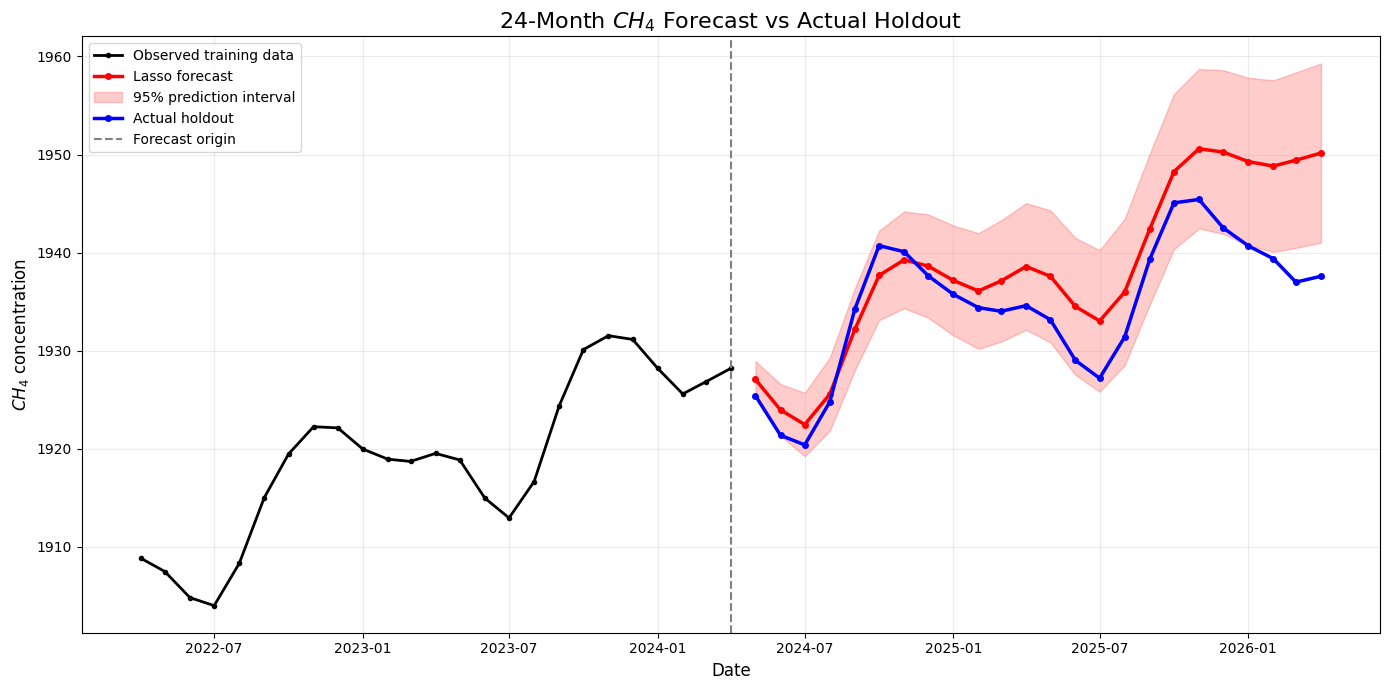

In [18]:
# Settings
zoom_history_months = 24
# Holdout data
holdout = holdout.sort_index()
# Determine forecast origin
last_training_date = holdout.index[0] - pd.offsets.MonthBegin(1)
# Select historical data immediately before holdout
zoom_start_date = (last_training_date
    - pd.DateOffset(months=zoom_history_months)
)
historical_zoom = historical_data.loc[
    historical_data.index >= zoom_start_date
]
# Create plot
plt.figure(figsize=(14, 7))

# 1. Historical observations used for training
plt.plot(historical_zoom.index,historical_zoom[target_col],
    color="black",linewidth=2,marker="o",markersize=3,
    label="Observed training data"
)

# 2. Lasso 24-month forecast
plt.plot(forecast_df.index,forecast_df["forecast"],
    color="red",linewidth=2.5,marker="o",markersize=4,
    label="Lasso forecast"
)

# 3. 95% prediction interval
plt.fill_between(forecast_df.index,forecast_df["lower_95"],
    forecast_df["upper_95"],color="red",alpha=0.20,
    label="95% prediction interval"
)

# 4. Actual holdout observations
plt.plot(holdout.index,holdout[target_col],
    color="blue",linewidth=2.5,marker="o",markersize=4,
    label="Actual holdout"
)

# 5. Forecast origin
plt.axvline(x=last_training_date,color="gray",
    linestyle="--",linewidth=1.5,label="Forecast origin"
)
# Formatting
plt.title("24-Month $CH_4$ Forecast vs Actual Holdout",fontsize=16)
plt.xlabel("Date",fontsize=12)
plt.ylabel("$CH_4$ concentration",fontsize=12)
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

## **7. One-Step-Ahead Holdout Forecast with Actual Updates Using Best Model**

In [19]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# 1. Settings
target_col = "average"
holdout_months = 24
best_alpha = 0.001082636733874054

# 2. Split data chronologically
df = df.sort_index()
training_data = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()
holdout = holdout.sort_index()
print("=" * 70)
print("DATA SPLIT")
print("=" * 70)
print("Training period:",training_data.index[0],
    "to",training_data.index[-1]
)
print("Holdout period:",holdout.index[0],
    "to",holdout.index[-1]
)
print()

# 3. Create training features
training_features = create_ch4_features(training_data,target_col=target_col)

# 4. Apply EXACT SAME feature selection
X_train = select_model_features(training_features,target_col=target_col)
y_train = training_features[target_col]

# 5. Define Elastic Net
final_lasso2 = Pipeline([("scaler", StandardScaler()),("model", ElasticNet(
        alpha=best_alpha,max_iter=100000
    ))
])

# 6. Fit ONLY on pre-holdout data
final_lasso2.fit(X_train,y_train)
print("=" * 70)
print("LASSO")
print("=" * 70)
print("Alpha:", best_alpha)
print("Training observations:", len(X_train))
print("Number of predictors:", X_train.shape[1])
print()

# 7. Create series containing ONLY information available
#    at each forecasting point
observed_series = training_data[target_col].copy()
observed_series = observed_series.sort_index()

# 8. Sequential one-step-ahead forecasting
holdout_predictions = []
for forecast_date in holdout.index:
    # At this point: observed_series contains:
    #   all training observations
    #   +
    #   ACTUAL holdout observations that have already occurred
    # It does not contain the current forecast_date.
    temp_df = pd.DataFrame({target_col: observed_series})
    # Add current date with a temporary placeholder.
    # This is safe because every target-derived predictor
    # in create_ch4_features() uses shift(1) or older.
    # Therefore the placeholder cannot enter the predictors
    # for forecast_date.
    temp_df.loc[forecast_date,target_col] = 0.0
    temp_df = temp_df.sort_index()
    # Engineer features
    temp_features = create_ch4_features(
        temp_df,target_col=target_col
    )
    # Apply SAME feature selection used for training
    temp_features = select_model_features(
        temp_features,target_col=target_col
    )
    # Make sure the forecast row exists
    if forecast_date not in temp_features.index:
        raise ValueError(f"Could not create features for {forecast_date}")
    # Extract predictors for CURRENT date
    X_future = temp_features.loc[[forecast_date]]
    # Force exactly the same column order as training
    X_future = X_future[X_train.columns]
    # Predict CURRENT date
    prediction = final_lasso2.predict(X_future)[0]
    # Retrieve ACTUAL value
    actual = holdout.loc[forecast_date,target_col]
    # Store prediction and actual
    holdout_predictions.append({"date": forecast_date,
        "actual": actual,"forecast": prediction
    })
    # Critical Step
    # We don't append the prediction.
    # We ppend the ACTUAL observed value.
    observed_series.loc[forecast_date] = actual

# 9. Create results dataframe
holdout_results = pd.DataFrame(holdout_predictions)
holdout_results = holdout_results.set_index("date")

# 10. Calculate errors
holdout_results["error"] = (holdout_results["actual"]
    - holdout_results["forecast"]
)
holdout_results["absolute_error"] = (holdout_results["error"].abs())
holdout_results["squared_error"] = (holdout_results["error"] ** 2)

# 11. Performance metrics
mae = (holdout_results["absolute_error"].mean())
rmse = np.sqrt(holdout_results["squared_error"].mean())
print("=" * 70)
print("ONE-STEP-AHEAD HOLDOUT PERFORMANCE")
print("=" * 70)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print()

# 12. Display results
print("=" * 70)
print("HOLDOUT PREDICTIONS")
print("=" * 70)
print(
    holdout_results[
        [
            "actual",
            "forecast",
            "error",
            "absolute_error"
        ]
    ].to_string(
        formatters={
            "actual": "{:.4f}".format,
            "forecast": "{:.4f}".format,
            "error": "{:.4f}".format,
            "absolute_error": "{:.4f}".format
        }
    )
)


DATA SPLIT
Training period: 1983-07-01 00:00:00 to 2024-04-01 00:00:00
Holdout period: 2024-05-01 00:00:00 to 2026-04-01 00:00:00

LASSO
Alpha: 0.001082636733874054
Training observations: 442
Number of predictors: 18

ONE-STEP-AHEAD HOLDOUT PERFORMANCE
MAE:  0.7171
RMSE: 0.9621

HOLDOUT PREDICTIONS
              actual  forecast   error absolute_error
date                                                 
2024-05-01 1925.4100 1927.0807 -1.6707         1.6707
2024-06-01 1921.3700 1921.1494  0.2206         0.2206
2024-07-01 1920.4000 1920.5912 -0.1912         0.1912
2024-08-01 1924.7900 1924.1974  0.5926         0.5926
2024-09-01 1934.2400 1931.8726  2.3674         2.3674
2024-10-01 1940.7100 1941.0304 -0.3204         0.3204
2024-11-01 1940.0900 1940.6115 -0.5215         0.5215
2024-12-01 1937.6200 1936.9141  0.7059         0.7059
2025-01-01 1935.7400 1935.8277 -0.0877         0.0877
2025-02-01 1934.3900 1934.6032 -0.2132         0.2132
2025-03-01 1934.0200 1935.2095 -1.1895         1.189

### **7.1 Constructing 95% Prediction Intervals for Holdout**
These are ONE-STEP-AHEAD predictions. Therefore, unlike the 24-month recursive forecast, we do NOT need to inflate uncertainty using sqrt(horizon). Each prediction is for one month ahead and uses all actual observations available up to the previous month.

ROLLING ONE-STEP-AHEAD HOLDOUT RESULTS
              actual  forecast  lower_95  upper_95   error absolute_error
date                                                                     
2024-05-01 1925.4100 1927.0807 1925.1821 1928.9794 -1.6707         1.6707
2024-06-01 1921.3700 1921.1494 1919.2508 1923.0480  0.2206         0.2206
2024-07-01 1920.4000 1920.5912 1918.6926 1922.4898 -0.1912         0.1912
2024-08-01 1924.7900 1924.1974 1922.2988 1926.0960  0.5926         0.5926
2024-09-01 1934.2400 1931.8726 1929.9740 1933.7712  2.3674         2.3674
2024-10-01 1940.7100 1941.0304 1939.1318 1942.9290 -0.3204         0.3204
2024-11-01 1940.0900 1940.6115 1938.7129 1942.5102 -0.5215         0.5215
2024-12-01 1937.6200 1936.9141 1935.0155 1938.8127  0.7059         0.7059
2025-01-01 1935.7400 1935.8277 1933.9291 1937.7263 -0.0877         0.0877
2025-02-01 1934.3900 1934.6032 1932.7046 1936.5018 -0.2132         0.2132
2025-03-01 1934.0200 1935.2095 1933.3109 1937.1082 -1.1895         1.1895

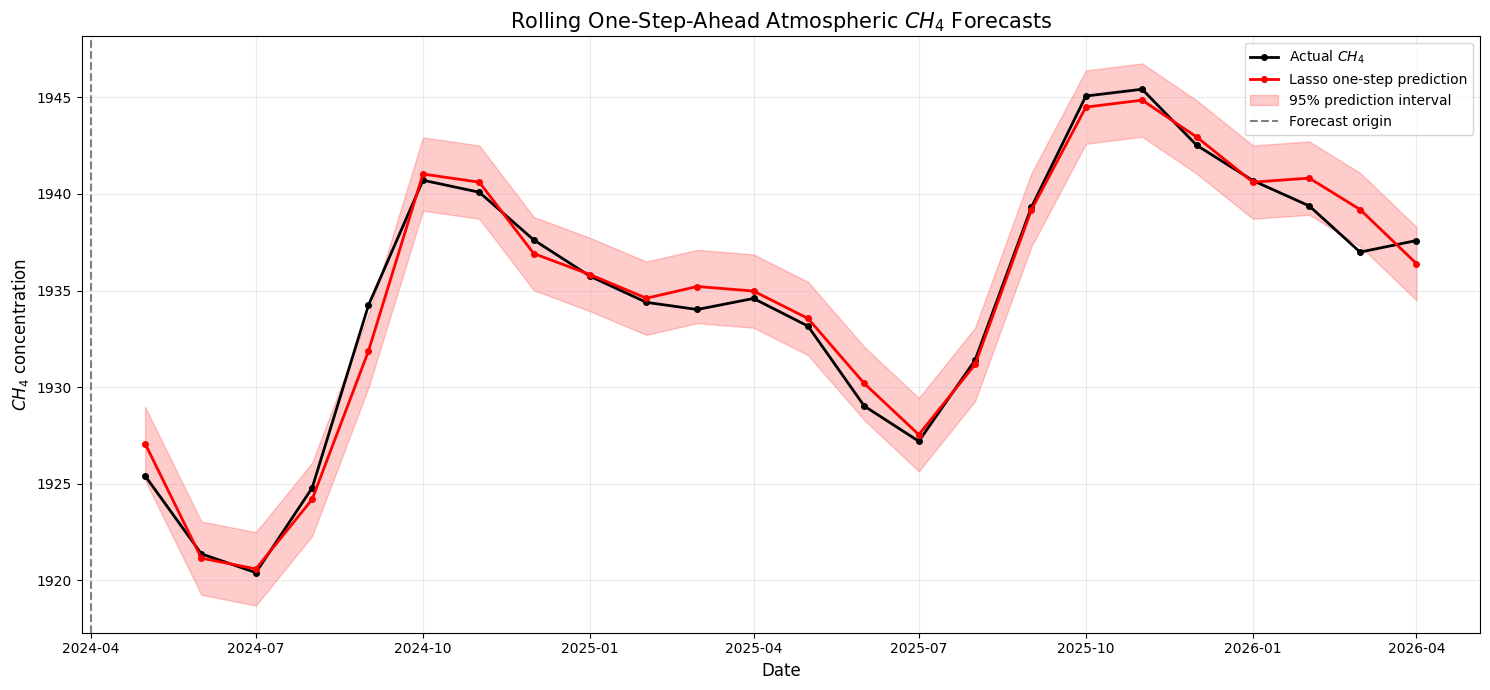

In [22]:
confidence_level = 0.95
z_value = 1.96

# Estimate residual standard deviation from the rolling
# one-step-ahead holdout predictions.
residual_std = (holdout_results["actual"]- holdout_results["forecast"]
).std(ddof=1)
# Add prediction intervals
holdout_results["lower_95"] = (holdout_results["forecast"]- z_value * residual_std)
holdout_results["upper_95"] = (holdout_results["forecast"]+ z_value * residual_std)

# 1. Display holdout results
print("=" * 70)
print("ROLLING ONE-STEP-AHEAD HOLDOUT RESULTS")
print("=" * 70)
print(
    holdout_results[
        [
            "actual",
            "forecast",
            "lower_95",
            "upper_95",
            "error",
            "absolute_error"
        ]
    ].to_string(
        formatters={
            "actual": "{:.4f}".format,
            "forecast": "{:.4f}".format,
            "lower_95": "{:.4f}".format,
            "upper_95": "{:.4f}".format,
            "error": "{:.4f}".format,
            "absolute_error": "{:.4f}".format
        }
    )
)

# 2. Plot rolling predictions + 95% CI against actual holdout
plt.figure(figsize=(15, 7))
# Actual holdout observations
plt.plot(holdout_results.index,holdout_results["actual"],
    color="black",linewidth=2,marker="o",markersize=4,
    label="Actual $CH_4$"
)
# Rolling one-step-ahead predictions
plt.plot(holdout_results.index,holdout_results["forecast"],
    color="red",linewidth=2,marker="o",markersize=4,
    label="Lasso one-step prediction"
)
# 95% prediction interval
plt.fill_between(holdout_results.index,holdout_results["lower_95"],
    holdout_results["upper_95"],color="red",alpha=0.20,
    label="95% prediction interval"
)
# Training / holdout boundary
plt.axvline(x=training_data.index[-1],color="gray",linestyle="--",
    linewidth=1.5,label="Forecast origin"
)
# Labels
plt.title("Rolling One-Step-Ahead Atmospheric $CH_4$ Forecasts",
    fontsize=15
)
plt.xlabel("Date",fontsize=12)
plt.ylabel("$CH_4$ concentration",fontsize=12)
# Legend and grid
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()